<a href="https://colab.research.google.com/github/Jags-08/cs-notes/blob/main/Image%20Acquisition%20and%20Sampling%20and%20quantization%20on%20Digital%20Image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

To study image acquisition and implement sampling and quantization on a digital image

IMAGE ACQUISATION - image is accuired and displayed in terms of
Shape = (height, width, channels)
3 channels RGB

Image Shape (Height, Width, Channels):
(374, 500, 3)


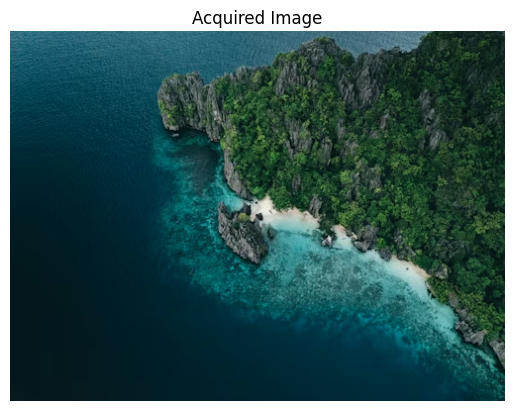

In [ ]:
# To study image acquisition and implement sampling and quantization on a digital image.

import cv2
import matplotlib.pyplot as plt
import numpy as np

# Read image (change path if needed)
img = cv2.imread('/content/DIP lab.avif')

# Check if image was loaded successfully
if img is None:
    print("Error: Could not load image. Please check the path and file name.")
else:
    # Convert BGR to RGB (important for matplotlib)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    print("Image Shape (Height, Width, Channels):")
    print(img.shape)

    # Display acquired image
    plt.imshow(img)
    plt.title("Acquired Image")
    plt.axis('off')
    plt.show()

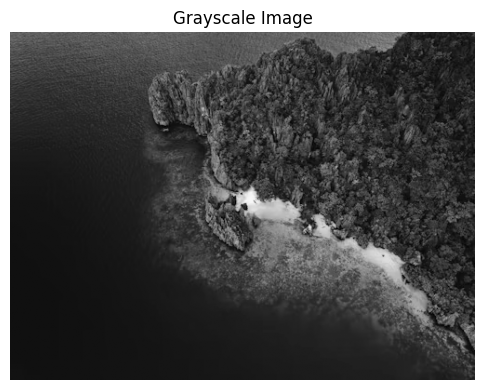

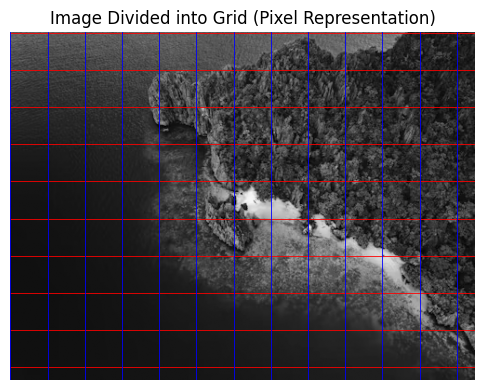

In [ ]:
#Convert to grayscale for simplicity
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(6,6))
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(gray, cmap='gray')
plt.title("Image Divided into Grid (Pixel Representation)")

#Draw grid lines
step = 40  # size of each grid block

# Horizontal lines
for i in range(0, gray.shape[0], step):
    plt.axhline(i, color='red', linewidth=0.6)

# Vertical lines
for j in range(0, gray.shape[1], step):
    plt.axvline(j, color='blue', linewidth=0.6)

plt.axis('off')
plt.show()

In [ ]:
# Print sample pixel intensity values
print("Pixel intensity values (sample):\n")
print(gray[0:10, 0:10])

Pixel intensity values (sample):

[[ 95  98  90  82  87  92  89  85  95  97]
 [ 98 102 101 102 102  97  94  99  94 102]
 [ 98 104 101  95  94  94  94  98  95 101]
 [ 92  91  90  95  98  91  87  94 103 105]
 [ 88  89  89  93  96  91  92 103 102 105]
 [ 97  98  96  99 110 109  94  82  94  96]
 [ 93  97  95  92  88  81  79  87  91  93]
 [101 106  99  89  91  97 100 102  90  86]
 [100 103 106 107 105 107 110 101  94  97]
 [ 93  94  99  92  92 100  91  84  87  98]]


In [ ]:
print("Pixel intensity values (sample):\n")
print(quantized[0:10, 0:10])

Pixel intensity values (sample):

[[80 96 80 80 80 80 80 80 80 96]
 [96 96 96 96 96 96 80 96 80 96]
 [96 96 96 80 80 80 80 96 80 96]
 [80 80 80 80 96 80 80 80 96 96]
 [80 80 80 80 96 80 80 96 96 96]
 [96 96 96 96 96 96 80 80 80 96]
 [80 96 80 80 80 80 64 80 80 80]
 [96 96 96 80 80 96 96 96 80 80]
 [96 96 96 96 96 96 96 96 80 96]
 [80 80 96 80 80 96 80 80 80 96]]


In [ ]:
print("Pixel intensity values (sample):\n")
print(img[0:10, 0:10])

Pixel intensity values (sample):

[[[ 50 111 129]
  [ 53 114 132]
  [ 45 106 124]
  [ 37  98 116]
  [ 42 103 121]
  [ 47 108 126]
  [ 44 105 123]
  [ 40 101 119]
  [ 51 111 129]
  [ 53 113 131]]

 [[ 53 114 132]
  [ 57 118 136]
  [ 56 117 135]
  [ 57 118 136]
  [ 57 118 136]
  [ 52 113 131]
  [ 49 110 128]
  [ 55 115 133]
  [ 50 110 128]
  [ 58 118 136]]

 [[ 53 114 132]
  [ 59 120 138]
  [ 56 117 135]
  [ 50 111 129]
  [ 49 110 128]
  [ 49 110 128]
  [ 50 110 128]
  [ 54 114 132]
  [ 53 110 127]
  [ 59 116 133]]

 [[ 47 108 126]
  [ 46 107 125]
  [ 45 106 124]
  [ 50 111 129]
  [ 53 114 132]
  [ 46 107 125]
  [ 43 103 121]
  [ 50 110 128]
  [ 61 118 135]
  [ 63 120 137]]

 [[ 43 104 122]
  [ 44 105 123]
  [ 44 105 123]
  [ 48 109 127]
  [ 51 112 130]
  [ 46 107 125]
  [ 47 108 126]
  [ 59 119 137]
  [ 60 117 134]
  [ 63 120 137]]

 [[ 52 113 131]
  [ 53 114 132]
  [ 51 112 130]
  [ 54 115 133]
  [ 65 126 144]
  [ 64 125 143]
  [ 49 110 128]
  [ 37  98 116]
  [ 50 110 126]
  [ 54 111 1

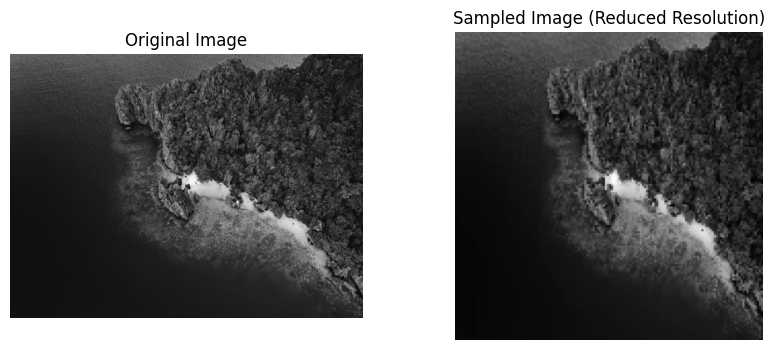

In [ ]:
sampled = cv2.resize(gray, (150, 150))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(sampled, cmap='gray')
plt.title("Sampled Image (Reduced Resolution)")
plt.axis('off')

plt.show()

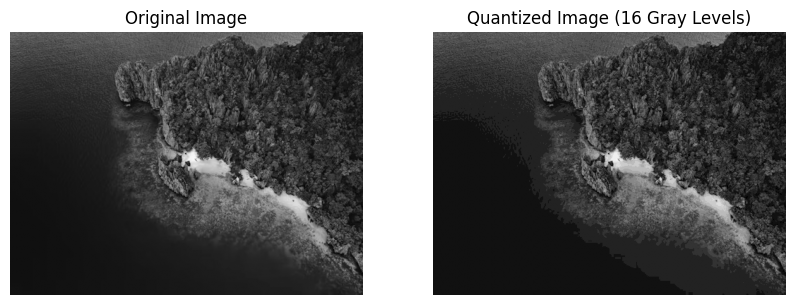

In [ ]:
levels = 16   # number of gray levels

quantized = np.floor(gray / (256/levels)) * (256/levels)
quantized = quantized.astype(np.uint8)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(quantized, cmap='gray')
plt.title("Quantized Image (16 Gray Levels)")
plt.axis('off')

plt.show()